In [120]:
import pandas as pd
import os 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from joblib import parallel_backend
from scipy.stats import mstats

In [121]:
root_dir = r'/home/check/DATA/university/yr3, hk1/DS111 - phân tích dữ liệu/Do_an/DS111/'

In [122]:
df = pd.read_csv(root_dir + 'Data/Silver/Silver_1.csv')
print(df.columns)


Index(['Country_Code', 'Year', 'Partner_Name', 'standard_name',
       'AHS_Weighted_Average_Percent', 'MFN_Weighted_Average_Percent',
       'AHS_Duty_Free_Tariff_Lines_Share_Percent', 'has_RCA',
       'has_Country_Growth', 'cc_rank', 'pv_rank', 'rl_rank', 'va_rank',
       'Log_Export', 'Log_Import', 'Tariff_Gap', 'Country_Growth_Percent'],
      dtype='object')


In [123]:
df.drop(columns=['Partner_Name'], inplace=True)
df.rename(columns={'standard_name': 'Country_Name'}, inplace=True)

In [124]:
df.describe()

,Year,AHS_Weighted_Average_Percent,MFN_Weighted_Average_Percent,AHS_Duty_Free_Tariff_Lines_Share_Percent,has_RCA,has_Country_Growth,cc_rank,pv_rank,rl_rank,va_rank,Log_Export,Log_Import,Tariff_Gap,Country_Growth_Percent
count,5623.000000,5623.000000,5623.000000,5623.000000,5623.000000,5623.00000,5540.000000,5571.000000,5614.000000,5595.000000,5623.000000,5623.000000,5623.000000,4126.000000
mean,2009.857194,4.979779,9.338014,57.236084,0.755646,0.73395,46.154386,44.760959,45.529925,45.547828,16.154083,15.624336,4.358234,4.289981
std,7.002062,4.522902,4.708389,18.812375,0.429741,0.44193,29.233939,28.669390,29.674160,29.478824,2.746895,3.093200,4.111100,10.411500
min,1996.000000,0.000000,1.770000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.322083,-31.940000,-62.280000
25%,2004.000000,1.790000,6.200000,41.990000,1.000000,0.00000,19.000000,19.600000,18.800000,19.200000,14.435726,13.609598,2.050000,-1.325000
50%,2010.000000,4.160000,8.490000,58.930000,1.000000,1.00000,44.300000,42.000000,45.000000,43.500000,16.102132,15.596026,3.570000,4.245000
75%,2016.000000,6.760000,11.610000,72.355000,1.000000,1.00000,69.900000,68.400000,68.600000,70.000000,18.027325,18.010012,6.140000,9.810000
max,2021.000000,52.210000,49.080000,100.000000,1.000000,1.00000,100.000000,100.000000,100.000000,100.000000,22.908755,22.803758,39.050000,174.000000


In [125]:
df.shape

(5623, 16)

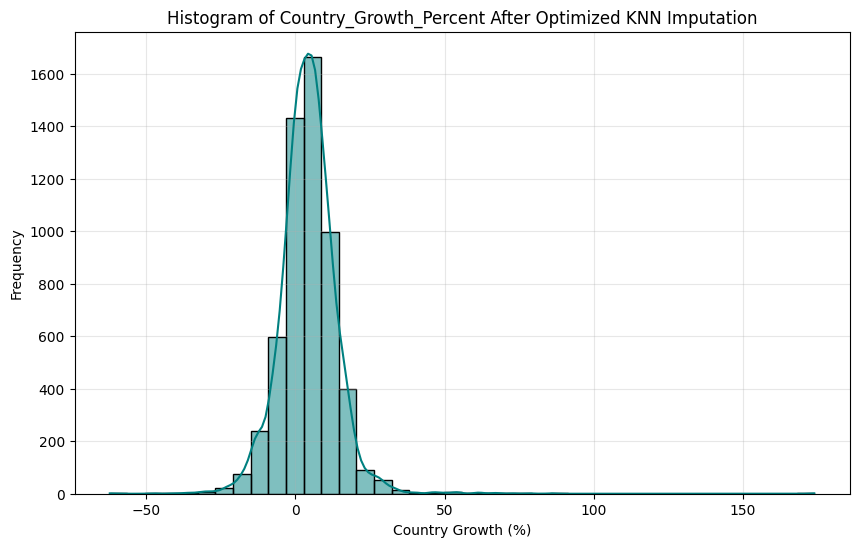


Thống kê sau imputation:
count    5623.000000
mean        4.279234
std         9.561809
min       -62.280000
25%        -0.885000
50%         4.193333
75%         9.430000
max       174.000000
Name: Country_Growth_Percent, dtype: float64


In [126]:
reduced_features = [
    'Log_Export',
    'Log_Import',
    'Tariff_Gap',
    'Year',
    'Country_Growth_Percent'
]

df_impute = df[reduced_features].copy()


scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_impute), columns=reduced_features)


imputer = KNNImputer(n_neighbors=3)

with parallel_backend('loky', n_jobs=-1):
    df_imputed_scaled = pd.DataFrame(
        imputer.fit_transform(df_scaled),
        columns=reduced_features
    )

df_imputed = pd.DataFrame(
    scaler.inverse_transform(df_imputed_scaled),
    columns=reduced_features
)

df['Country_Growth_Percent'] = df_imputed['Country_Growth_Percent']

plt.figure(figsize=(10, 6))
sns.histplot(df['Country_Growth_Percent'], bins=40, kde=True, color='teal')
plt.title('Histogram of Country_Growth_Percent After Optimized KNN Imputation')
plt.xlabel('Country Growth (%)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

print("\nThống kê sau imputation:")
print(df['Country_Growth_Percent'].describe())

In [127]:
df.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5623 entries, 0 to 5622
Data columns (total 16 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Country_Code                              5623 non-null   object 
 1   Year                                      5623 non-null   int64  
 2   Country_Name                              5623 non-null   object 
 3   AHS_Weighted_Average_Percent              5623 non-null   float64
 4   MFN_Weighted_Average_Percent              5623 non-null   float64
 5   AHS_Duty_Free_Tariff_Lines_Share_Percent  5623 non-null   float64
 6   has_RCA                                   5623 non-null   int64  
 7   has_Country_Growth                        5623 non-null   int64  
 8   cc_rank                                   5540 non-null   float64
 9   pv_rank                                   5571 non-null   float64
 10  rl_rank                             

In [128]:
print(df.describe())

              Year  AHS_Weighted_Average_Percent  \
count  5623.000000                   5623.000000   
mean   2009.857194                      4.979779   
std       7.002062                      4.522902   
min    1996.000000                      0.000000   
25%    2004.000000                      1.790000   
50%    2010.000000                      4.160000   
75%    2016.000000                      6.760000   
max    2021.000000                     52.210000   

       MFN_Weighted_Average_Percent  AHS_Duty_Free_Tariff_Lines_Share_Percent  \
count                   5623.000000                               5623.000000   
mean                       9.338014                                 57.236084   
std                        4.708389                                 18.812375   
min                        1.770000                                  0.000000   
25%                        6.200000                                 41.990000   
50%                        8.490000          

In [129]:
df['Tariff_Gap'] = df['Tariff_Gap'].clip(lower=0)

df['Country_Growth_Percent'] = mstats.winsorize(
    df['Country_Growth_Percent'], 
    limits=[0.01, 0.01]  
)

In [130]:
df['Effective_Tariff'] = df['AHS_Weighted_Average_Percent'] * (
    1 - df['AHS_Duty_Free_Tariff_Lines_Share_Percent'] / 100
)

In [131]:
df.describe()

/home/check/Programs/anaconda3/envs/myenv/lib/python3.11/site-packages/numpy/lib/function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/home/check/Programs/anaconda3/envs/myenv/lib/python3.11/site-packages/numpy/lib/function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/home/check/Programs/anaconda3/envs/myenv/lib/python3.11/site-packages/numpy/lib/function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/home/check/Programs/anaconda3/envs/myenv/lib/python3.11/site-packages/numpy/lib/function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/home/check/Programs/anaconda3/envs/myenv/lib/python3.11/site-packages/numpy/lib/function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/home/chec

,Year,AHS_Weighted_Average_Percent,MFN_Weighted_Average_Percent,AHS_Duty_Free_Tariff_Lines_Share_Percent,has_RCA,has_Country_Growth,cc_rank,pv_rank,rl_rank,va_rank,Log_Export,Log_Import,Tariff_Gap,Country_Growth_Percent,Effective_Tariff
count,5623.000000,5623.000000,5623.000000,5623.000000,5623.000000,5623.00000,5540.000000,5571.000000,5614.000000,5595.000000,5623.000000,5623.000000,5623.000000,5623.000000,5623.000000
mean,2009.857194,4.979779,9.338014,57.236084,0.755646,0.73395,46.154386,44.760959,45.529925,45.547828,16.154083,15.624336,4.526278,4.204350,2.410284
std,7.002062,4.522902,4.708389,18.812375,0.429741,0.44193,29.233939,28.669390,29.674160,29.478824,2.746895,3.093200,3.664245,8.557513,2.619153
min,1996.000000,0.000000,1.770000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.322083,0.000000,-18.200000,0.000000
25%,2004.000000,1.790000,6.200000,41.990000,1.000000,0.00000,19.000000,19.600000,18.800000,19.200000,14.435726,13.609598,2.050000,-0.885000,0.504164
50%,2010.000000,4.160000,8.490000,58.930000,1.000000,1.00000,44.300000,42.000000,45.000000,43.500000,16.102132,15.596026,3.570000,4.193333,1.582347
75%,2016.000000,6.760000,11.610000,72.355000,1.000000,1.00000,69.900000,68.400000,68.600000,70.000000,18.027325,18.010012,6.140000,9.430000,3.484544
max,2021.000000,52.210000,49.080000,100.000000,1.000000,1.00000,100.000000,100.000000,100.000000,100.000000,22.908755,22.803758,39.050000,29.160000,24.879465


In [132]:
df.to_csv(r'/home/check/DATA/university/yr3, hk1/DS111 - phân tích dữ liệu/Do_an/DS111/Data/Gold/Gold_1.csv', index=False,encoding='utf-8-sig')

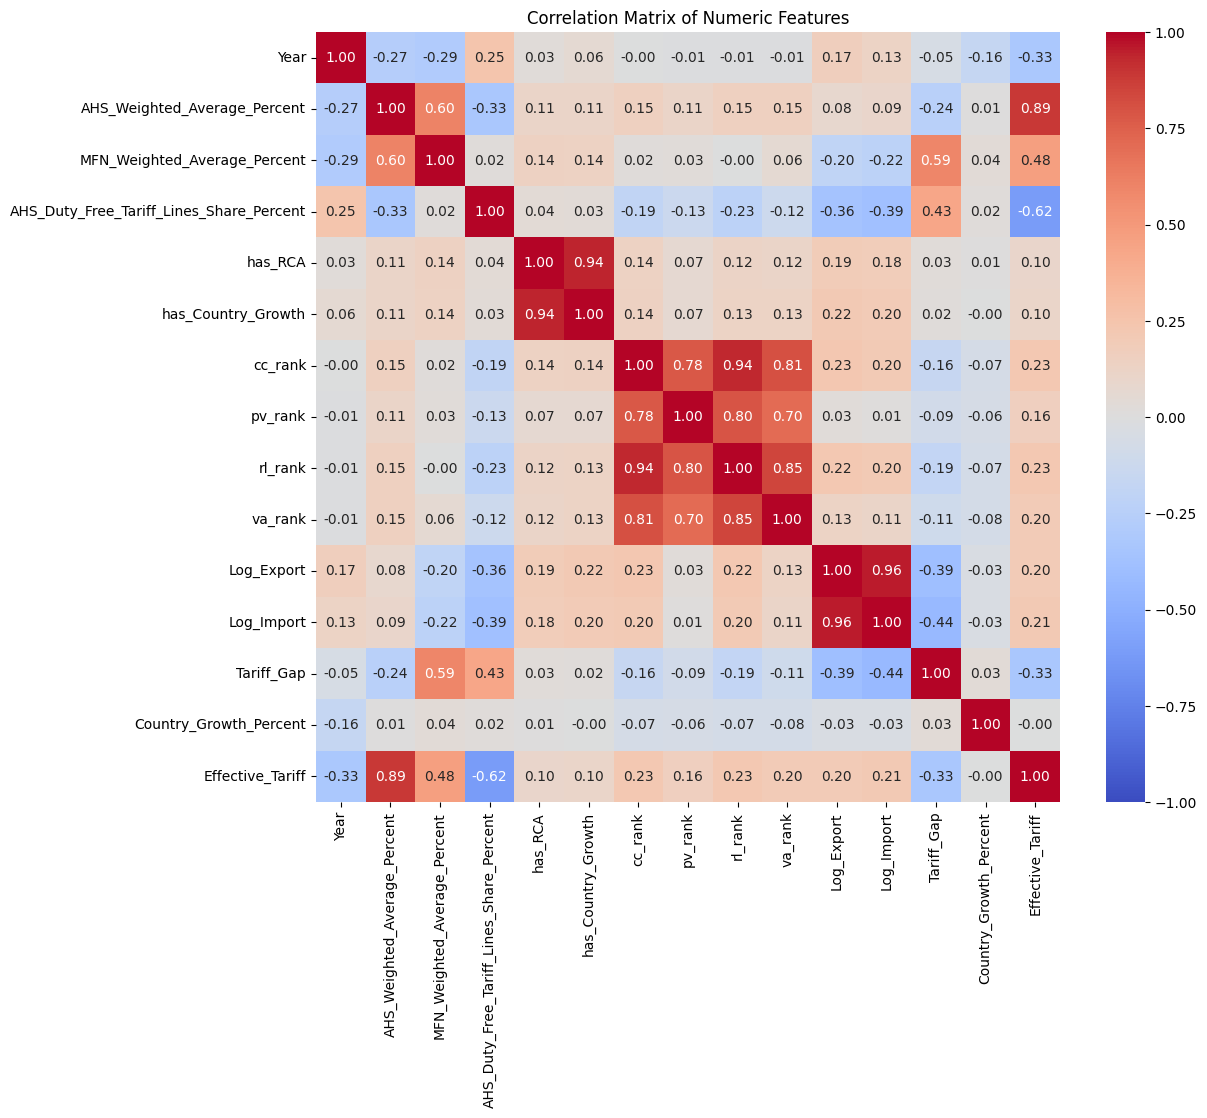

In [133]:
numeric_features = df.select_dtypes(include=['float64', 'int64']).columns
corr = df[numeric_features].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

In [134]:
df.head()

,Country_Code,Year,Country_Name,AHS_Weighted_Average_Percent,MFN_Weighted_Average_Percent,AHS_Duty_Free_Tariff_Lines_Share_Percent,has_RCA,has_Country_Growth,cc_rank,pv_rank,rl_rank,va_rank,Log_Export,Log_Import,Tariff_Gap,Country_Growth_Percent,Effective_Tariff
0,ABW,2004,Aruba,3.31,5.69,56.76,1,1,85.2,80.6,80.8,73.1,14.770925,14.745080,2.38,1.73,1.431244
1,ABW,2005,Aruba,2.22,5.78,47.31,1,1,88.3,96.1,78.0,85.6,14.960064,15.217246,3.56,8.43,1.169718
2,ABW,2006,Aruba,2.76,6.11,39.90,1,1,88.3,96.1,72.7,80.3,15.051433,15.286031,3.35,0.55,1.658760
3,ABW,2007,Aruba,2.39,5.91,52.70,1,1,88.3,96.6,75.1,78.4,14.917213,15.362467,3.52,3.42,1.130470
4,ABW,2008,Aruba,2.78,7.56,47.17,1,1,87.4,96.2,76.4,79.3,14.880180,15.537949,4.78,-0.06,1.468674


In [135]:
df.shape

(5623, 17)